# Correlated-R prototype: core + halo approximation to $R^{-1}$

Mock setting: $P = P_x \times P_y$ serial "MPI tasks" (`r_matrix.MockComm`), observations start on **random** tasks, then

1. spatial ownership (row-major $i + P_x j$, `[low, high)` cells, clamp at $x_{max}, y_{max}$)
2. redistribution (Alltoall counts + Alltoallv records, frozen value plan for recurring use)
3. halo discovery (owner pushes records to ranks whose core $\oplus h$ contains them; receiver filters exactly)
4. frozen communication map (request / translate / count+hash confirm)
5. local Cholesky on core + halo, keep the core part of $R_{loc}^{-1} d_{loc}$, send back to the original tasks

$R_{ij} = \sigma_i\sigma_j\,[\alpha\,\rho_{GC}(\|x_i-x_j\|; c) + (1-\alpha)\delta_{ij}]$, Gaspari–Cohn with length scale $\ell = c$ and support $2c$.
Validation against the exact global solve $z^* = R^{-1}d$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle

from r_matrix import Config, run, sweep

# Palette (validated categorical slots 1-3 + neutral context)
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
GREY, INK, INK2 = "#c9c8c2", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6, "lines.linewidth": 2,
    "lines.markersize": 6, "legend.frameon": False,
})
pd.set_option("display.float_format", "{:.3g}".format)

def draw_grid(ax, dec, **kw):
    d = dec.domain
    for i in range(dec.px + 1):
        ax.axvline(d.xmin + i * dec.dx, color=INK2, lw=0.6, **kw)
    for j in range(dec.py + 1):
        ax.axhline(d.ymin + j * dec.dy, color=INK2, lw=0.6, **kw)
    ax.set_xlim(d.xmin, d.xmax); ax.set_ylim(d.ymin, d.ymax); ax.set_aspect("equal"); ax.grid(False)

## Acceptance thresholds (placeholders — agree before running, deck slide 8)

In [2]:
BASE = Config()            # 3000 obs, 12 x 9 domain, 4 x 3 tasks, c = l = 0.5, alpha = 0.8
REL_L2_MAX = 1e-3          # numerical gate on ||z~ - z*|| / ||z*||
REL_MAX_MAX = 1e-2         # numerical gate on max|z~ - z*| / max|z*|
HALO_CORE_PEAK_MAX = 6.0   # cost gate on peak halo/core ratio
dens = BASE.n_obs / (BASE.domain.lx * BASE.domain.ly) * BASE.c**2
print(f"P = {BASE.px*BASE.py}, obs per l^2 = {dens:.1f}, subdomain = {BASE.domain.lx/BASE.px:g} x {BASE.domain.ly/BASE.py:g} "
      f"= {BASE.domain.lx/BASE.px/BASE.c:g} l x {BASE.domain.ly/BASE.py/BASE.c:g} l")

P = 12, obs per l^2 = 6.9, subdomain = 3 x 3 = 6 l x 6 l


## 1. Random initial ownership → spatial ownership → core + halo
Task 5 is highlighted; all other observations in grey.

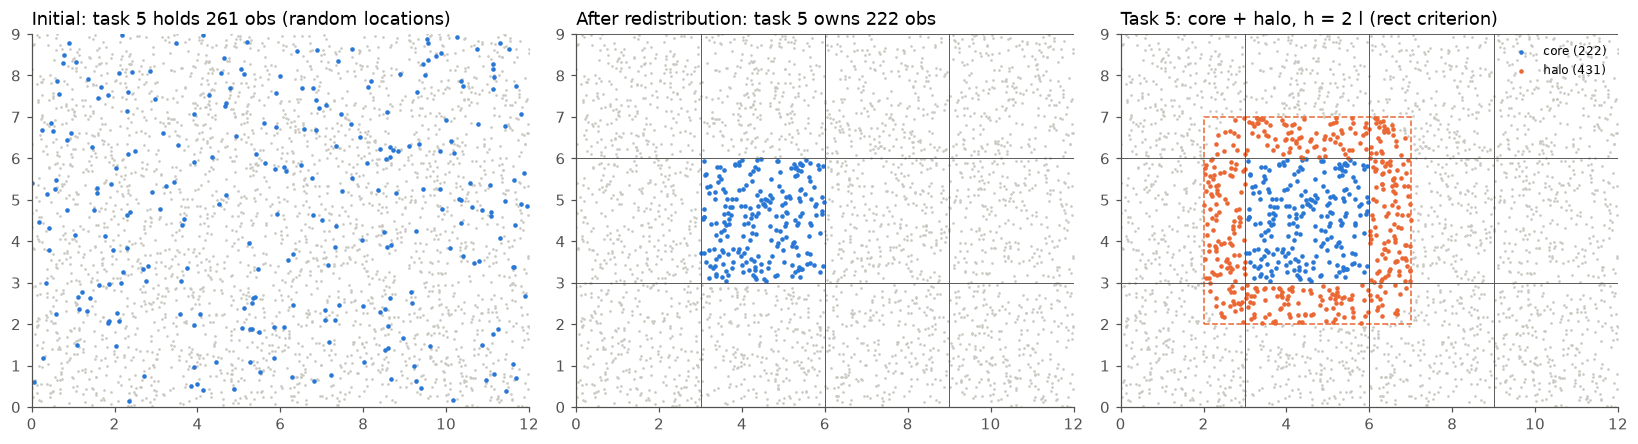

In [3]:
res = run(BASE, h=2 * BASE.c)
dec, r0 = res.decomp, 5
allobs = np.concatenate(res.obs_init)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
for ax in axs:
    ax.scatter(allobs["x"], allobs["y"], s=3, c=GREY, lw=0)
o = res.obs_init[r0]
axs[0].scatter(o["x"], o["y"], s=9, c=C1, lw=0)
axs[0].set_title(f"Initial: task {r0} holds {len(o)} obs (random locations)", loc="left")
axs[0].set_xlim(0, 12); axs[0].set_ylim(0, 9); axs[0].set_aspect("equal"); axs[0].grid(False)

o = res.owned[r0]
draw_grid(axs[1], dec)
axs[1].scatter(o["x"], o["y"], s=9, c=C1, lw=0)
axs[1].set_title(f"After redistribution: task {r0} owns {len(o)} obs", loc="left")

h = res.config.h
x0, x1, y0, y1 = dec.cell_rect(r0)
draw_grid(axs[2], dec)
axs[2].add_patch(Rectangle((x0 - h, y0 - h), x1 - x0 + 2*h, y1 - y0 + 2*h, fill=False, ec=C2, lw=1, ls="--"))
axs[2].scatter(o["x"], o["y"], s=9, c=C1, lw=0, label=f"core ({len(o)})")
hh = res.halos[r0]
axs[2].scatter(hh["x"], hh["y"], s=9, c=C2, lw=0, label=f"halo ({len(hh)})")
axs[2].set_title(f"Task {r0}: core + halo, h = {h/BASE.c:g} l (rect criterion)", loc="left")
axs[2].legend(loc="upper right", fontsize=8)
plt.tight_layout();

In [4]:
m = res.metrics
print("owned counts:", m["owned"])
print(f"rel L2 = {m['rel_l2']:.2e}, rel max = {m['rel_max']:.2e}, residual (global) = {m['residual_global']:.2e}, "
      f"residual (distributed) = {m['residual_distributed']:.2e}")
pd.DataFrame(res.comm.stats.table()).T

owned counts: {'min': 222, 'mean': 250.0, 'max': 269, 'cv': 0.05145872132107443}
rel L2 = 6.87e-03, rel max = 1.37e-02, residual (global) = 2.52e-02, residual (distributed) = 2.52e-02


,calls,bytes,messages,max_peers
setup:redistribute:counts,1,1056,132,11
setup:redistribute:records,1,132144,132,11
setup:halo:counts,1,1056,132,11
setup:halo:records,1,169872,58,8
setup:map:counts,1,1056,132,11
setup:map:requests,1,26992,58,8
setup:map:confirm_counts,1,1056,132,11
setup:map:confirm,1,928,58,8
recurring:forward,1,22024,132,11
recurring:halo,1,26992,58,8


## 2. Main go/no-go experiment: sweep $h/\ell$
Error vs cost. Recurring bytes = forward + halo exchange + reverse of **one** application of $R^{-1}$ (8 B/value).
Local compute scales with the local problem size $n_{loc}$ (dense Cholesky $\propto n_{loc}^3$ in setup, $n_{loc}^2$ per apply).

In [5]:
H_OVER_L = [0.5, 1, 1.5, 2, 3, 4, 5, 6]
df = pd.DataFrame(sweep("h", [BASE.c * x for x in H_OVER_L], BASE))
df[["h_over_l", "rel_l2", "rel_max", "residual_global", "halo_core_ratio_peak", "local_n_max",
    "bytes_apply", "bytes_apply_halo", "bytes_setup", "halo_peers_max", "time_setup", "time_apply"]]

,h_over_l,rel_l2,rel_max,residual_global,halo_core_ratio_peak,local_n_max,bytes_apply,bytes_apply_halo,bytes_setup,halo_peers_max,time_setup,time_apply
0,0.5,0.0506,0.123,0.227,0.374,341,49632,5584,176816,7,0.0342,0.00138
1,1,0.0251,0.0409,0.102,0.887,440,56152,12104,223752,8,0.0453,0.00281
2,1.5,0.0138,0.028,0.0614,1.34,575,63280,19232,275952,8,0.0544,0.00245
3,2,0.00687,0.0137,0.0252,1.94,696,71040,26992,334160,8,0.0895,0.0044
4,3,0.00171,0.00334,0.00713,3.2,981,87768,43720,458168,8,0.137,0.00794
5,4,0.00048,0.00104,0.00178,4.68,1267,105936,61888,599024,8,0.178,0.00679
6,5,0.000124,0.000206,0.000534,6.39,1642,127272,83224,764408,8,0.287,0.0207
7,6,2.37e-05,6.84e-05,9.1e-05,8.27,2057,149520,105472,934400,8,0.475,0.0229


smallest h/l passing all gates: 4.0


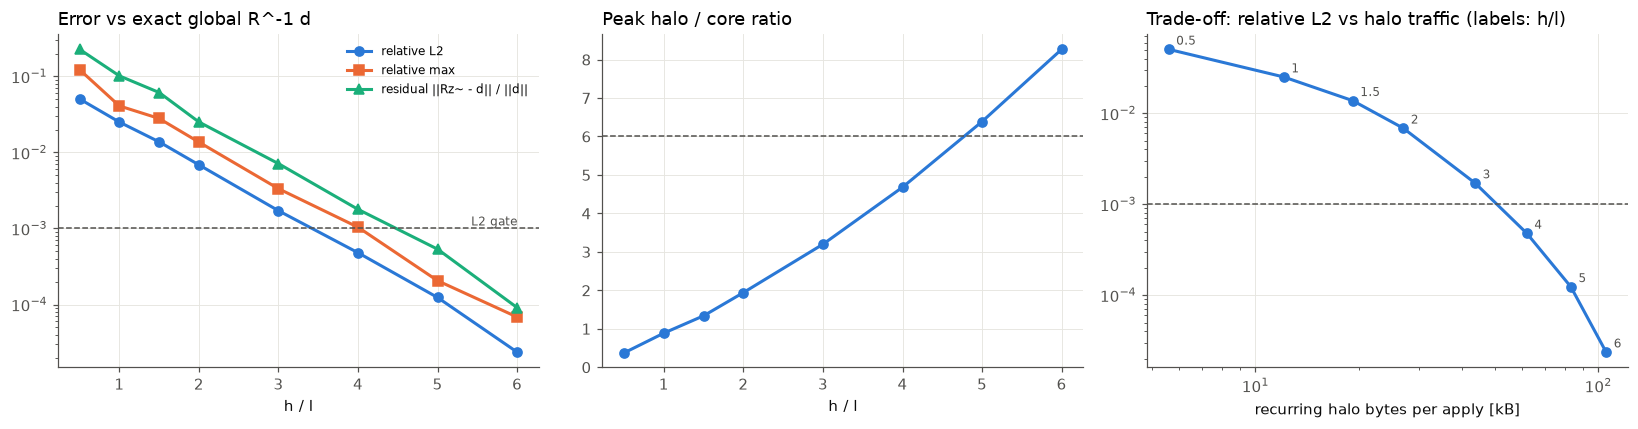

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
ax = axs[0]
ax.semilogy(df.h_over_l, df.rel_l2, "o-", c=C1, label="relative L2")
ax.semilogy(df.h_over_l, df.rel_max, "s-", c=C2, label="relative max")
ax.semilogy(df.h_over_l, df.residual_global, "^-", c=C3, label="residual ||Rz~ - d|| / ||d||")
ax.axhline(REL_L2_MAX, color=INK2, lw=1, ls="--"); ax.text(df.h_over_l.max(), REL_L2_MAX, " L2 gate", va="bottom", ha="right", color=INK2, fontsize=8)
ax.set_xlabel("h / l"); ax.set_title("Error vs exact global R^-1 d", loc="left"); ax.legend(fontsize=8)

ax = axs[1]
ax.plot(df.h_over_l, df.halo_core_ratio_peak, "o-", c=C1)
ax.axhline(HALO_CORE_PEAK_MAX, color=INK2, lw=1, ls="--")
ax.set_xlabel("h / l"); ax.set_ylim(0); ax.set_title("Peak halo / core ratio", loc="left")

ax = axs[2]
ax.loglog(df.bytes_apply_halo / 1e3, df.rel_l2, "o-", c=C1)
for _, row in df.iterrows():
    ax.annotate(f"{row.h_over_l:g}", (row.bytes_apply_halo / 1e3, row.rel_l2), textcoords="offset points",
                xytext=(5, 3), fontsize=8, color=INK2)
ax.axhline(REL_L2_MAX, color=INK2, lw=1, ls="--")
ax.set_xlabel("recurring halo bytes per apply [kB]"); ax.set_title("Trade-off: relative L2 vs halo traffic (labels: h/l)", loc="left")
plt.tight_layout()

ok = df[(df.rel_l2 <= REL_L2_MAX) & (df.rel_max <= REL_MAX_MAX) & (df.halo_core_ratio_peak <= HALO_CORE_PEAK_MAX)]
print("smallest h/l passing all gates:", ok.h_over_l.min() if len(ok) else "none -> NO-GO at this configuration")

## 3. Sensitivity: nugget and observation density
The decay rate of $R^{-1}$ entries (hence the halo needed) depends on conditioning: the smaller the nugget $1-\alpha$, the slower the decay.

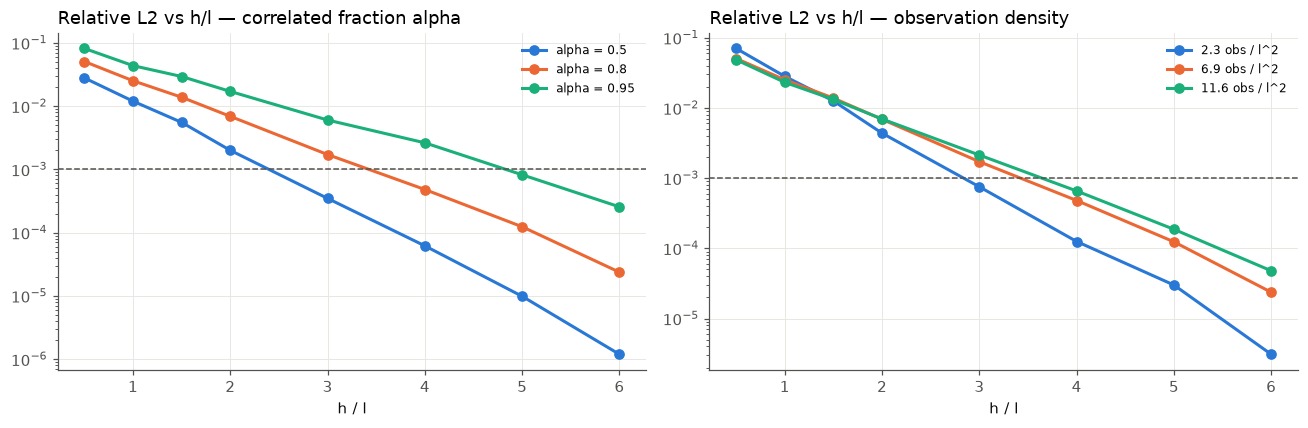

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for col, alpha in zip((C1, C2, C3), (0.5, 0.8, 0.95)):
    d = pd.DataFrame(sweep("h", [BASE.c * x for x in H_OVER_L], BASE, alpha=alpha))
    axs[0].semilogy(d.h_over_l, d.rel_l2, "o-", c=col, label=f"alpha = {alpha}")
axs[0].axhline(REL_L2_MAX, color=INK2, lw=1, ls="--")
axs[0].set_xlabel("h / l"); axs[0].set_title("Relative L2 vs h/l — correlated fraction alpha", loc="left"); axs[0].legend(fontsize=8)

for col, n in zip((C1, C2, C3), (1000, 3000, 5000)):
    d = pd.DataFrame(sweep("h", [BASE.c * x for x in H_OVER_L], BASE, n_obs=n))
    dens = n / (BASE.domain.lx * BASE.domain.ly) * BASE.c**2
    axs[1].semilogy(d.h_over_l, d.rel_l2, "o-", c=col, label=f"{dens:.1f} obs / l^2")
axs[1].axhline(REL_L2_MAX, color=INK2, lw=1, ls="--")
axs[1].set_xlabel("h / l"); axs[1].set_title("Relative L2 vs h/l — observation density", loc="left"); axs[1].legend(fontsize=8)
plt.tight_layout();

## 4. Robustness: decompositions × observation patterns (fixed $h/\ell = 3$)

In [8]:
rows = []
for px, py in [(2, 2), (4, 3), (8, 6)]:
    for pattern in ["uniform", "clustered", "coincident", "boundary"]:
        m = run(BASE, px=px, py=py, pattern=pattern, h=3 * BASE.c).metrics
        rows.append({"P": f"{px}x{py}", "pattern": pattern, "rel_l2": m["rel_l2"], "rel_max": m["rel_max"],
                     "residual": m["residual_global"], "owned_cv": m["owned"]["cv"], "owned_max": m["owned"]["max"],
                     "halo/core peak": m["halo_core_ratio_peak"], "n_loc max": m["local_n_max"],
                     "halo kB/apply": m["bytes_apply_halo"] / 1e3, "peers max": m["halo_peers_max"]})
pd.DataFrame(rows).set_index(["P", "pattern"])

rel_l2  rel_max  residual  owned_cv  owned_max  \
P   pattern                                                       
2x2 uniform     0.00111  0.00265   0.00452   0.00938        755   
    clustered  0.000754  0.00625   0.00765     0.583       1314   
    coincident 0.000981  0.00366   0.00383    0.0292        770   
    boundary    0.00115  0.00281    0.0102     0.146        906   
4x3 uniform     0.00171  0.00334   0.00713    0.0515        269   
    clustered   0.00128  0.00642    0.0167      1.06        933   
    coincident  0.00161  0.00281   0.00693    0.0736        269   
    boundary    0.00166  0.00323    0.0109     0.112        316   
8x6 uniform     0.00253  0.00328    0.0105     0.121         78   
    clustered    0.0022   0.0092    0.0297      1.97        582   
    coincident  0.00235  0.00389   0.00944     0.129         78   
    boundary    0.00268  0.00447    0.0153     0.129         81   

                halo/core peak  n_loc max  halo kB/apply  peers max  
P   pattern                                                          
2x2 uniform              0.661       1243           15.4          3  
    clustered              5.3       2132           22.9          3  
    coincident           0.661       1252           15.1          3  
    boundary             0.956       1362           16.6          3  
4x3 uniform                3.2        981           43.7          8  
    clustered             10.5       1717           44.7          8  
    coincident            3.63        976           43.5          8  
    boundary                 3        978           44.1          8  
8x6 uniform                 10        551            138          8  
    clustered             93.5       1674            136          8  
    coincident            10.1        553            138          8  
    boundary              8.69        543            133          8

### Halo criterion: rectangle distance vs distance to owned observations (geometric vs k-d tree must agree)

In [9]:
rows = []
for crit, meth in [("rect", "brute"), ("obs", "brute"), ("obs", "kdtree")]:
    r_ = run(BASE, h=3 * BASE.c, criterion=crit, halo_method=meth)
    m = r_.metrics
    rows.append({"criterion": crit, "method": meth, "rel_l2": m["rel_l2"], "halo total": m["halo_total"],
                 "candidates": m["candidates_total"], "halo/core peak": m["halo_core_ratio_peak"],
                 "setup halo [s]": r_.timings["setup_halo"],
                 "halo ids": [tuple(h["global_id"]) for h in r_.halos]})
t = pd.DataFrame(rows)
print("obs-criterion halo ID sets identical (brute vs k-d tree):", t["halo ids"][1] == t["halo ids"][2])
t.drop(columns="halo ids")

obs-criterion halo ID sets identical (brute vs k-d tree): True


,criterion,method,rel_l2,halo total,candidates,halo/core peak,setup halo [s]
0,rect,brute,0.00171,5465,5774,3.2,0.00326
1,obs,brute,0.00214,5089,5774,2.91,0.03
2,obs,kdtree,0.00214,5089,5774,2.91,0.0184


## 5. Where does the error live?
Per-observation $|z̃ - z^*|$ (log scale) with the task boundaries: error should concentrate near core edges, where the truncated halo cuts the $R^{-1}$ footprint.

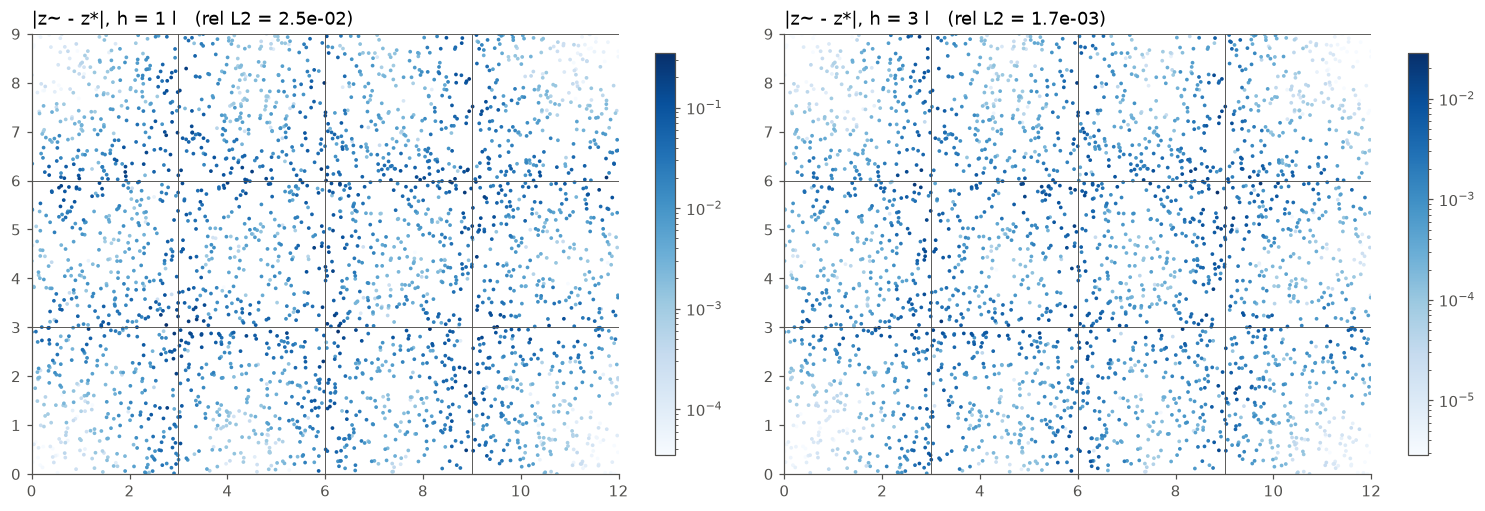

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, hl in zip(axs, (1, 3)):
    r_ = run(BASE, h=hl * BASE.c)
    err = np.abs(np.concatenate(r_.owned_errors()))
    ow = np.concatenate(r_.owned)
    order = np.argsort(err)
    sc = ax.scatter(ow["x"][order], ow["y"][order], c=err[order], s=6, lw=0, cmap="Blues",
                    norm=LogNorm(vmin=max(err.max() * 1e-4, 1e-12), vmax=err.max()))
    draw_grid(ax, r_.decomp)
    ax.set_title(f"|z~ - z*|, h = {hl} l   (rel L2 = {r_.metrics['rel_l2']:.1e})", loc="left")
    fig.colorbar(sc, ax=ax, shrink=0.85)
plt.tight_layout();

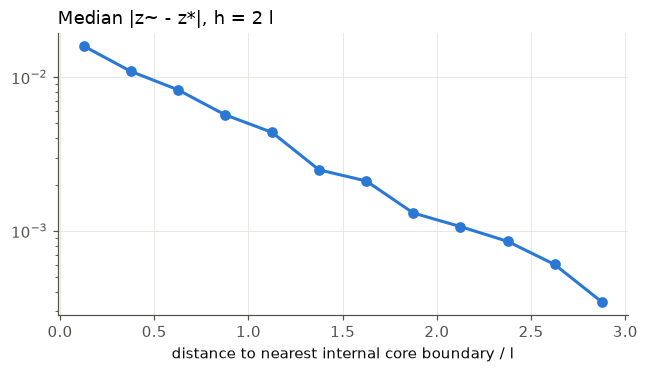

In [11]:
# Error vs distance of the observation to its core boundary
r_ = run(BASE, h=2 * BASE.c)
err = np.abs(np.concatenate(r_.owned_errors()))
D = BASE.domain
dist = []
for r, o in enumerate(r_.owned):
    x0, x1, y0, y1 = r_.decomp.cell_rect(r)
    # distances to the four cell edges; domain edges are not internal boundaries
    edges = [(o["x"] - x0, np.isclose(x0, D.xmin)), (x1 - o["x"], np.isclose(x1, D.xmax)),
             (o["y"] - y0, np.isclose(y0, D.ymin)), (y1 - o["y"], np.isclose(y1, D.ymax))]
    dist.append(np.minimum.reduce([np.full(len(o), np.inf) if outer else e for e, outer in edges]))
dist = np.concatenate(dist) / BASE.c
bins = np.arange(0, 3.25, 0.25)
k = np.digitize(dist, bins)
med = [np.median(err[k == i]) if np.any(k == i) else np.nan for i in range(1, len(bins))]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(bins[:-1] + 0.125, med, "o-", c=C1)
ax.set_xlabel("distance to nearest internal core boundary / l"); ax.set_title("Median |z~ - z*|, h = 2 l", loc="left")
plt.tight_layout();

## 6. Geostationary-imager-like observations: contour maps
`pattern="geostationary"`: a regular pixel grid covering the whole domain (about 72 × 42 pixels, spacing ≈ 0.33 l), each pixel jittered by ±15 % (navigation noise).
The coverage is near-uniform, so $d$, $R^{-1}d$ and the error can be drawn as contour maps (triangulation of the pixel centres).
The black lines are the MPI subdomains.

3024 pixels, owned cv = 0.018, rel L2 = 9.80e-03, rel max = 2.41e-02


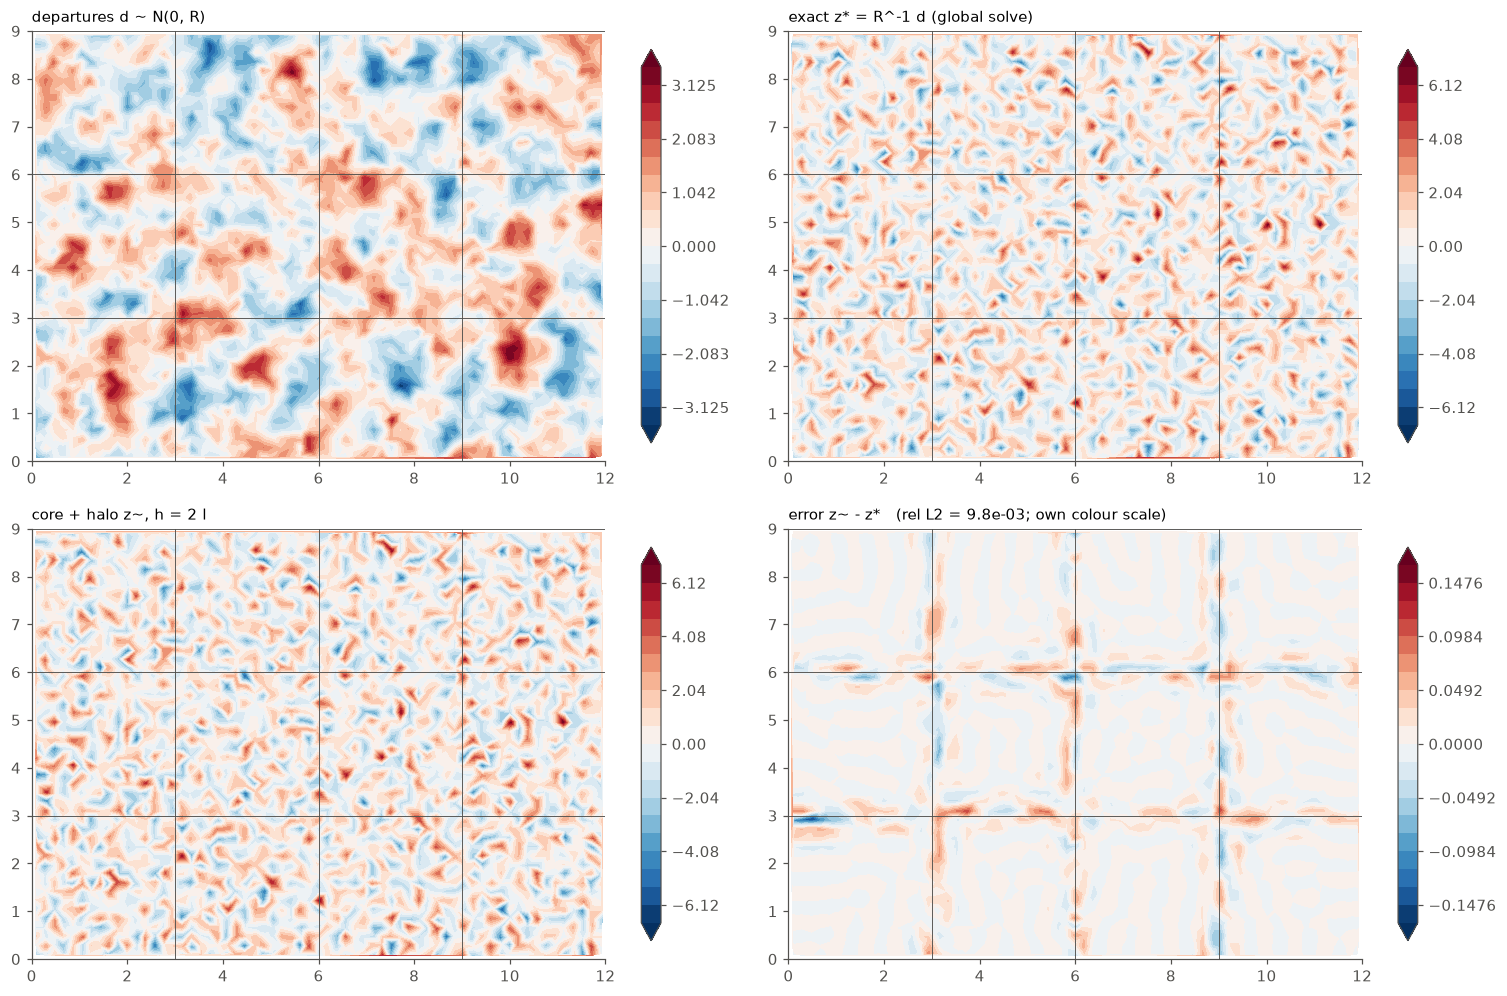

In [12]:
import matplotlib.tri as mtri

def field(res, values_owned):
    # (x, y, v) over all ranks, in owned order
    ow = np.concatenate(res.owned)
    return ow["x"], ow["y"], np.concatenate(values_owned)

def contour(ax, res, values_owned, vmax=None, cmap="RdBu_r", levels=21, title=""):
    x, y, v = field(res, values_owned)
    vmax = vmax or np.abs(v).max()
    cs = ax.tricontourf(mtri.Triangulation(x, y), v, levels=np.linspace(-vmax, vmax, levels),
                        cmap=cmap, extend="both")
    draw_grid(ax, res.decomp)
    ax.set_title(title, loc="left", fontsize=10)
    return cs

GEO = dict(pattern="geostationary")
geo = run(BASE, h=2 * BASE.c, **GEO)
m = geo.metrics
print(f"{m['n_valid']} pixels, owned cv = {m['owned']['cv']:.3f}, rel L2 = {m['rel_l2']:.2e}, rel max = {m['rel_max']:.2e}")

d_owned = [o["value"] for o in geo.owned]
zref_owned = [z - e for z, e in zip(geo.z_owned, geo.owned_errors())]
err_owned = geo.owned_errors()
zmax = max(np.abs(np.concatenate(zref_owned)).max(), np.abs(np.concatenate(geo.z_owned)).max())

fig, axs = plt.subplots(2, 2, figsize=(14, 9.2))
fig.colorbar(contour(axs[0, 0], geo, d_owned, title="departures d ~ N(0, R)"), ax=axs[0, 0], shrink=0.85)
fig.colorbar(contour(axs[0, 1], geo, zref_owned, vmax=zmax, title="exact z* = R^-1 d (global solve)"), ax=axs[0, 1], shrink=0.85)
fig.colorbar(contour(axs[1, 0], geo, geo.z_owned, vmax=zmax, title=f"core + halo z~, h = {geo.config.h_over_l:g} l"), ax=axs[1, 0], shrink=0.85)
emax = np.abs(np.concatenate(err_owned)).max()
fig.colorbar(contour(axs[1, 1], geo, err_owned, vmax=emax,
             title=f"error z~ - z*   (rel L2 = {m['rel_l2']:.1e}; own colour scale)"), ax=axs[1, 1], shrink=0.85)
plt.tight_layout();

### Error maps as the halo widens (shared log scale)
The error is confined to bands along the internal subdomain edges, and the bands fade as $h/\ell$ grows.

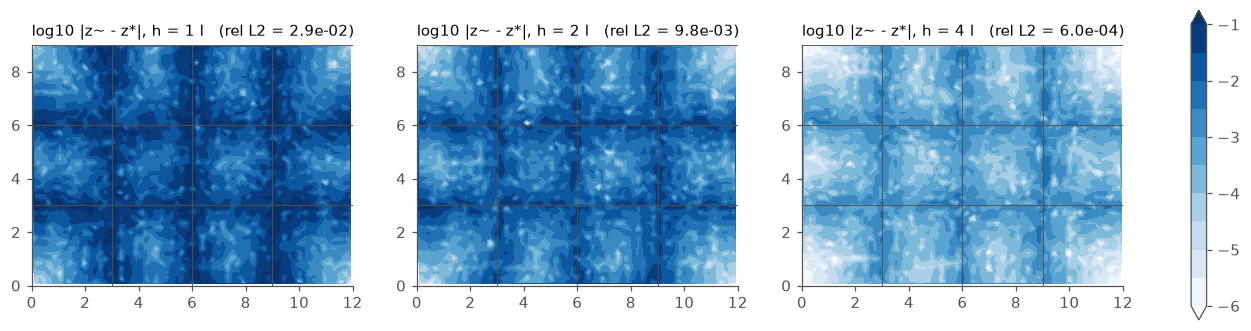

In [13]:
HS = (1, 2, 4)
runs = {hl: run(BASE, h=hl * BASE.c, **GEO) for hl in HS}
lev = np.linspace(-6, -1, 11)
fig, axs = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, hl in zip(axs, HS):
    r_ = runs[hl]
    x, y, e = field(r_, r_.owned_errors())
    cs = ax.tricontourf(mtri.Triangulation(x, y), np.log10(np.abs(e) + 1e-300), levels=lev,
                        cmap="Blues", extend="both")
    draw_grid(ax, r_.decomp)
    ax.set_title(f"log10 |z~ - z*|, h = {hl} l   (rel L2 = {r_.metrics['rel_l2']:.1e})", loc="left", fontsize=10)
fig.colorbar(cs, ax=axs, shrink=0.85);

### Footprint of $R^{-1}$ for one pixel near a subdomain corner
Apply $R^{-1}$ to a unit vector $e_k$ at a pixel close to the corner shared by tasks 1, 2, 5 and 6.
The exact response is a column of the dense $R^{-1}$. In the approximation, every task computes its own part of the response from its local core + halo problem, so the response is cut off wherever $e_k$ lies outside a task's halo.
The dashed rectangle is the core + halo of the task that owns the pixel (log scale; the exact column decays by about a decade per ℓ).

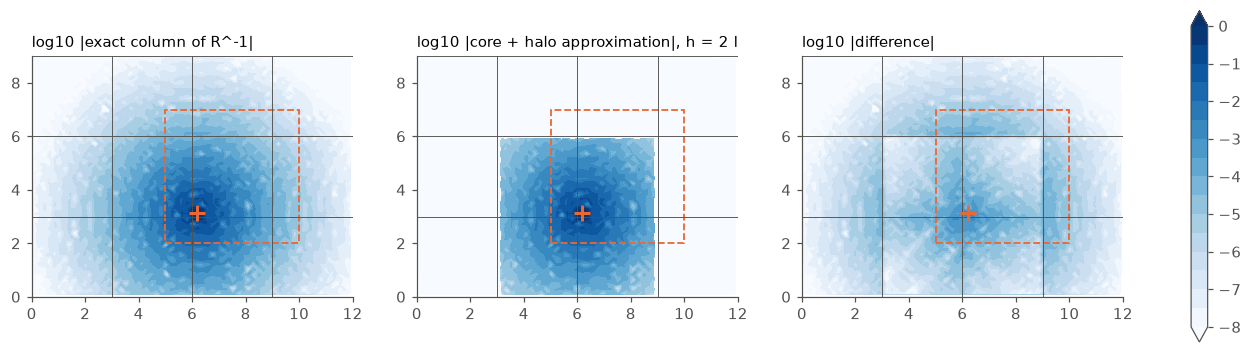

In [14]:
res_fp = runs[2]
allinit = np.concatenate(res_fp.obs_init)
k = np.argmin(np.hypot(allinit["x"] - 6.1, allinit["y"] - 3.1))
e_k = np.zeros(len(allinit)); e_k[k] = 1.0
e_orig = np.split(e_k, np.cumsum([len(o) for o in res_fp.obs_init])[:-1])

_, z_fp = res_fp.apply_Rinv(e_orig, tag="footprint")
z_fp_exact_orig = res_fp.apply_Rinv_exact(e_orig)
# exact response in owned order
gid_init = np.concatenate([o["global_id"] for o in res_fp.obs_init]); zex = np.concatenate(z_fp_exact_orig)
srt = np.argsort(gid_init)
z_fp_exact = [zex[srt][np.searchsorted(gid_init[srt], o["global_id"])] for o in res_fp.owned]

owner = res_fp.decomp.owner(allinit["x"][k], allinit["y"][k])
x0, x1, y0, y1 = res_fp.decomp.cell_rect(owner); h = res_fp.config.h
diff = [a - b for a, b in zip(z_fp, z_fp_exact)]
lev = np.linspace(-8, 0, 17)
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))
titles = ["log10 |exact column of R^-1|", "log10 |core + halo approximation|, h = 2 l", "log10 |difference|"]
for ax, vals, t in zip(axs, (z_fp_exact, z_fp, diff), titles):
    x, y, v = field(res_fp, vals)
    cs = ax.tricontourf(mtri.Triangulation(x, y), np.log10(np.abs(v) + 1e-300), levels=lev, cmap="Blues", extend="both")
    draw_grid(ax, res_fp.decomp)
    ax.add_patch(Rectangle((x0 - h, y0 - h), x1 - x0 + 2*h, y1 - y0 + 2*h, fill=False, ec=C2, lw=1.2, ls="--"))
    ax.plot(allinit["x"][k], allinit["y"][k], "+", c=C2, ms=10, mew=2)
    ax.set_title(t, loc="left", fontsize=10)
fig.colorbar(cs, ax=axs, shrink=0.85);


### Geostationary sweep

,h_over_l,rel_l2,rel_max,residual_global,halo_core_ratio_peak,local_n_max,bytes_apply_halo,owned_cv
0,0.5,0.0617,0.13,0.29,0.363,339,5536,0.0185
1,1,0.029,0.0581,0.123,0.849,453,12912,0.0185
2,1.5,0.0155,0.04,0.0644,1.24,549,19496,0.0185
3,2,0.0098,0.0241,0.0404,1.71,664,26368,0.0185
4,3,0.00232,0.00524,0.00968,2.87,949,43632,0.0185
5,4,0.000598,0.00119,0.00244,4.28,1294,63360,0.0185
6,5,0.000191,0.00043,0.000924,5.65,1629,82816,0.0185
7,6,3.96e-05,0.000119,0.000184,7.36,2051,106392,0.0185


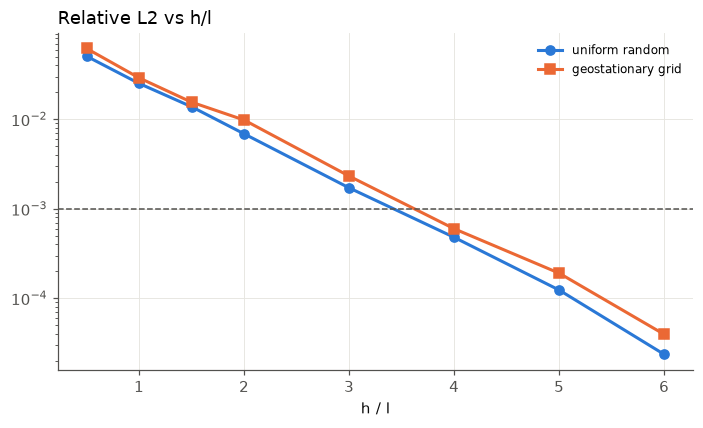

In [15]:
dg = pd.DataFrame(sweep("h", [BASE.c * x for x in H_OVER_L], BASE, **GEO))
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogy(df.h_over_l, df.rel_l2, "o-", c=C1, label="uniform random")
ax.semilogy(dg.h_over_l, dg.rel_l2, "s-", c=C2, label="geostationary grid")
ax.axhline(REL_L2_MAX, color=INK2, lw=1, ls="--")
ax.set_xlabel("h / l"); ax.set_title("Relative L2 vs h/l", loc="left"); ax.legend(fontsize=8)
plt.tight_layout()
dg[["h_over_l", "rel_l2", "rel_max", "residual_global", "halo_core_ratio_peak", "local_n_max", "bytes_apply_halo", "owned_cv"]]

## Decision checklist (deck slide 8)
| Gate | Evidence |
|---|---|
| REDISTRIBUTION | `check_redistribution` runs inside every `run()`; tests cover NaN/out-of-domain rejection, empty/skewed ranks, boundary points, duplicates |
| HALO + MAP | geometric vs k-d tree ID sets identical; map handshake checks count + hash; exchanged halo values equal owner values (tests) |
| NUMERICAL | sweep in §2 vs exact global solve (rel L2, rel max, residual) |
| ROBUSTNESS | §4 table across decompositions and patterns |
| COST | setup / recurring bytes, peers, halo/core ratio, local size |
| DECISION | smallest passing $h/\ell$ printed in §2 against the placeholder thresholds |